# Week 4 · Task 2 — What "95% confident" actually means (1,000 experiments)

**Roadmap task:** *Simulate 1,000 experiments. Build a 95% confidence interval in each. Count how many contain the true answer. It should be about 950. Now you actually understand what "95% confident" means.*

This is also **Gate 1, question 4**: *write the correct meaning of a 95% confidence interval, and the common wrong one.*

**What this notebook shows**

1. 1,000 simulated experiments, each with its own 95% interval (t-interval **and** bootstrap).
2. The count that contain the truth — and the picture of 100 of them.
3. The correct interpretation vs the common wrong ones.
4. When "95%" quietly becomes 85%: small samples from skewed data.
5. How interval width shrinks with sample size ($1/\sqrt n$).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from mathkit.bootstrap import bootstrap_distribution

FIG = pathlib.Path("figures"); FIG.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
rng = np.random.default_rng(95)

## 1. The setup

We play "nature": we **know** the true answer, which never happens in real life. Say the true average waiting time at a clinic is exactly **20 minutes** and waiting times are Normal with SD 6. Each "experiment" is a researcher who records $n = 30$ patients and builds a 95% interval for the mean. We run 1,000 independent researchers.

In [2]:
TRUE_MEAN, SD, n, n_experiments = 20.0, 6.0, 30, 1000
t_crit = stats.t.ppf(0.975, df=n - 1)          # ≈ 2.045 for n = 30

def t_interval(x, confidence=0.95):
    """Classic interval for the mean:  x̄ ± t* · s/√n"""
    tc = stats.t.ppf(1 - (1 - confidence) / 2, df=len(x) - 1)
    se = x.std(ddof=1) / np.sqrt(len(x))
    return x.mean() - tc * se, x.mean() + tc * se

def boot_interval(x, n_boot=2000, seed=None):
    reps = bootstrap_distribution(x, np.mean, n_boot=n_boot, rng=seed)
    return tuple(np.quantile(reps, [0.025, 0.975]))

t_ints, b_ints, means = [], [], []
for i in range(n_experiments):
    x = rng.normal(TRUE_MEAN, SD, n)             # one researcher's data
    means.append(x.mean())
    t_ints.append(t_interval(x))
    b_ints.append(boot_interval(x, seed=i))
t_ints, b_ints = np.array(t_ints), np.array(b_ints)

t_hit = (t_ints[:, 0] <= TRUE_MEAN) & (TRUE_MEAN <= t_ints[:, 1])
b_hit = (b_ints[:, 0] <= TRUE_MEAN) & (TRUE_MEAN <= b_ints[:, 1])
print(f"t-interval:         {t_hit.sum()} of {n_experiments} intervals contain the true mean  ({t_hit.mean():.1%})")
print(f"bootstrap interval: {b_hit.sum()} of {n_experiments} intervals contain the true mean  ({b_hit.mean():.1%})")

# How much wobble should we expect around 950 purely by chance? (Binomial!)
sd_count = np.sqrt(n_experiments * 0.95 * 0.05)
print(f"\nExpected: 950 ± {sd_count:.1f}  (Binomial(1000, 0.95) standard deviation) - so anything ~936-964 is on target.")

t-interval:         954 of 1000 intervals contain the true mean  (95.4%)
bootstrap interval: 933 of 1000 intervals contain the true mean  (93.3%)

Expected: 950 ± 6.9  (Binomial(1000, 0.95) standard deviation) - so anything ~936-964 is on target.


About 950 — as promised. The bootstrap version usually lands a little *below* 950 at $n = 30$: the percentile bootstrap is known to be slightly too narrow for small samples (it doesn't include the extra uncertainty that the $t$-distribution adds). Keep that in mind; section 4 makes it bigger.

## 2. The picture that makes it click

The first 100 experiments. Each horizontal line is one researcher's interval. **The truth (dashed line) never moves. The intervals do.** About 5 in 100 miss.

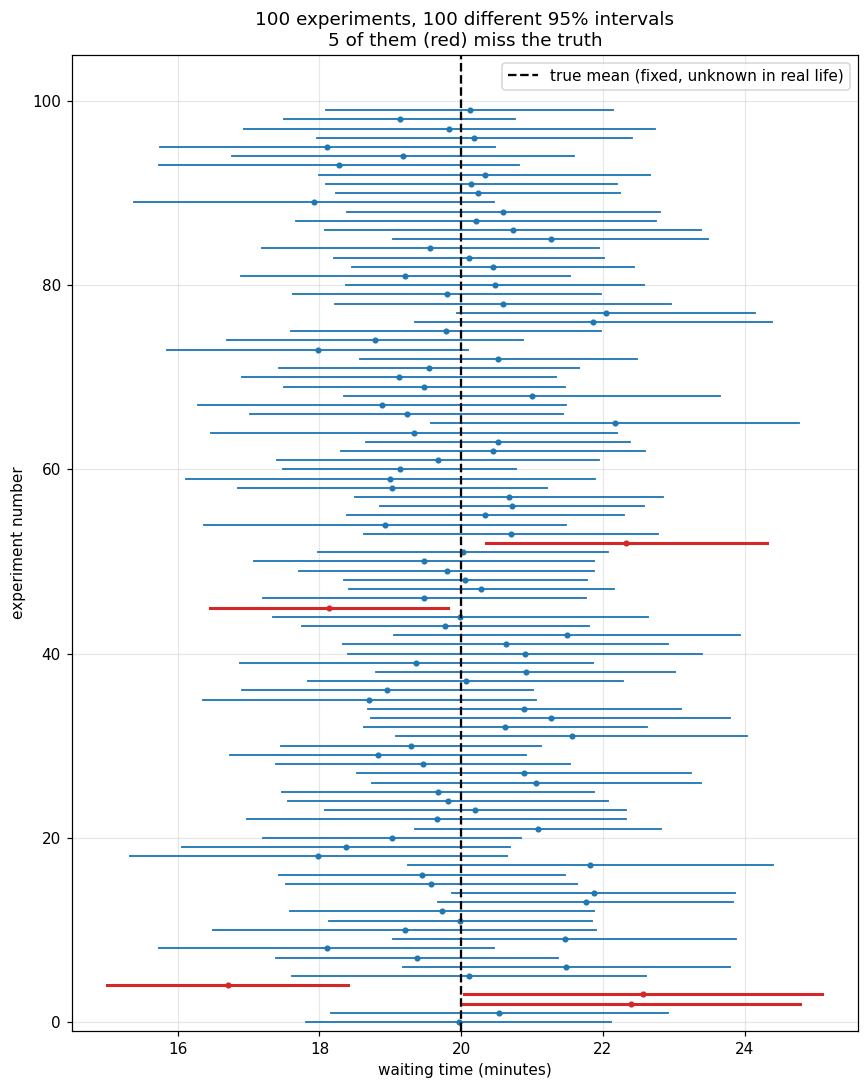

In [3]:
show = 100
fig, ax = plt.subplots(figsize=(8, 10))
for i in range(show):
    lo, hi = t_ints[i]
    color = "tab:blue" if t_hit[i] else "tab:red"
    ax.plot([lo, hi], [i, i], color=color, lw=2 if not t_hit[i] else 1.2)
    ax.plot(means[i], i, "o", color=color, ms=3)
ax.axvline(TRUE_MEAN, color="k", ls="--", lw=1.5, label="true mean (fixed, unknown in real life)")
ax.set_xlabel("waiting time (minutes)"); ax.set_ylabel("experiment number")
ax.set_title(f"100 experiments, 100 different 95% intervals\n{show - t_hit[:show].sum()} of them (red) miss the truth")
ax.legend(loc="upper right"); ax.set_ylim(-1, show + 5)   # headroom for the legend
fig.tight_layout(); fig.savefig(FIG / "w4_ci_coverage_100.png", dpi=150); plt.show()

## 3. The correct meaning — write this down word for word

> ✅ **Correct:** "If we repeated this whole procedure — collect a sample, build an interval — many times, **95% of the intervals built this way would contain the true value.**" The 95% is a property of the **method**, not of any one interval.

> ❌ **Wrong (the common one):** "There is a 95% probability that the true mean is between 18.0 and 22.5."

Why is that wrong? After you've computed *your* interval, the true mean is a fixed number — it is either inside $[18.0, 22.5]$ or it isn't. There's nothing random left. In the picture above, each individual line either touches the dashed line or it doesn't; none of them "95%-touches" it. The randomness was in the *sampling*, before you looked.

Other wrong statements you'll hear:

| wrong statement | why it's wrong |
|---|---|
| "95% of the data falls inside the interval" | That's a *prediction/reference* interval. A CI is about the **mean** — it's much narrower than the data's spread, and gets narrower with more data. |
| "If I repeat the study, there's a 95% chance the new mean falls in my interval" | Your interval is itself centred on a noisy estimate; the actual chance is lower (about 83% for two same-size studies). |
| "A wider interval means the method is worse" | A wider interval honestly reports more uncertainty (small $n$, noisy data). |

(If you *want* the statement "95% probability the parameter is in here", that's a Bayesian **credible interval** — it needs a prior, Week 3 style. Different tool, different meaning.)

In [4]:
x_demo = rng.normal(TRUE_MEAN, SD, n)
lo, hi = t_interval(x_demo)
print(f"one researcher's 95% CI for the mean: [{lo:.1f}, {hi:.1f}]  (width {hi - lo:.1f} min)")
print(f"range covering the middle 95% of individual waiting times in that sample: "
      f"[{np.quantile(x_demo, 0.025):.1f}, {np.quantile(x_demo, 0.975):.1f}]  <- NOT the same thing")

one researcher's 95% CI for the mean: [18.0, 22.5]  (width 4.4 min)
range covering the middle 95% of individual waiting times in that sample: [8.1, 30.2]  <- NOT the same thing


## 4. When "95%" isn't really 95%

The t-interval's guarantee assumes the sample mean is (close to) Normal. By the CLT (Week 3) that's true for large $n$ — but with **skewed data and small $n$**, the promise quietly breaks. Let's measure the *actual* coverage for a heavily skewed population (lognormal, like incomes or delivery times) as $n$ grows.

In [5]:
sigma_log = 1.0
skew_true_mean = np.exp(0.5 * sigma_log ** 2)          # true mean of a lognormal(0, 1) = e^{1/2}
ns = [5, 10, 20, 40, 80, 160, 320]
cov_t, cov_b = [], []
for nn in ns:
    tc = stats.t.ppf(0.975, nn - 1)
    hits_t = hits_b = 0
    for i in range(1000):
        x = rng.lognormal(0, sigma_log, nn)
        se = x.std(ddof=1) / np.sqrt(nn)
        hits_t += (x.mean() - tc * se <= skew_true_mean <= x.mean() + tc * se)
        reps = bootstrap_distribution(x, np.mean, n_boot=1000, rng=i)
        lo, hi = np.quantile(reps, [0.025, 0.975])
        hits_b += (lo <= skew_true_mean <= hi)
    cov_t.append(hits_t / 1000); cov_b.append(hits_b / 1000)
    print(f"n = {nn:>3}:  t-interval covers {cov_t[-1]:.1%}   bootstrap covers {cov_b[-1]:.1%}")

n =   5:  t-interval covers 83.0%   bootstrap covers 72.2%


n =  10:  t-interval covers 85.3%   bootstrap covers 81.8%


n =  20:  t-interval covers 86.8%   bootstrap covers 85.8%


n =  40:  t-interval covers 88.4%   bootstrap covers 88.5%


n =  80:  t-interval covers 92.0%   bootstrap covers 91.3%


n = 160:  t-interval covers 92.9%   bootstrap covers 92.6%


n = 320:  t-interval covers 94.2%   bootstrap covers 93.7%


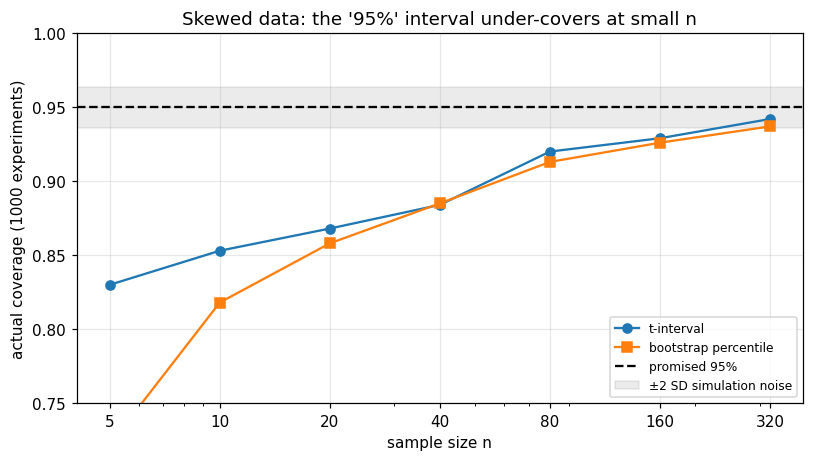

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.semilogx(ns, cov_t, "o-", label="t-interval")
ax.semilogx(ns, cov_b, "s-", label="bootstrap percentile")
ax.axhline(0.95, color="k", ls="--", label="promised 95%")
ax.axhspan(0.95 - 2 * 0.0069, 0.95 + 2 * 0.0069, color="k", alpha=0.08, label="±2 SD simulation noise")
ax.set_xticks(ns, ns); ax.set_xlabel("sample size n"); ax.set_ylabel("actual coverage (1000 experiments)")
ax.set_ylim(0.75, 1.0); ax.set_title("Skewed data: the '95%' interval under-covers at small n")
ax.legend(fontsize=8); fig.tight_layout(); fig.savefig(FIG / "w4_coverage_vs_n.png", dpi=150); plt.show()

**Lesson:** "95%" is a *promise that depends on assumptions*. With skewed data and a few dozen observations, both intervals miss the truth noticeably more than 5% of the time — mostly because a small sample usually *under-represents the long right tail*, so both the mean and the spread come out too small. The fix is more data, a better method (BCa, or a transformation such as logs), or at least an honest sentence in your limitations section.

## 5. More data → narrower intervals, but slowly

Width of a CI for the mean ∝ $\sigma/\sqrt n$. Four times the data buys half the width.

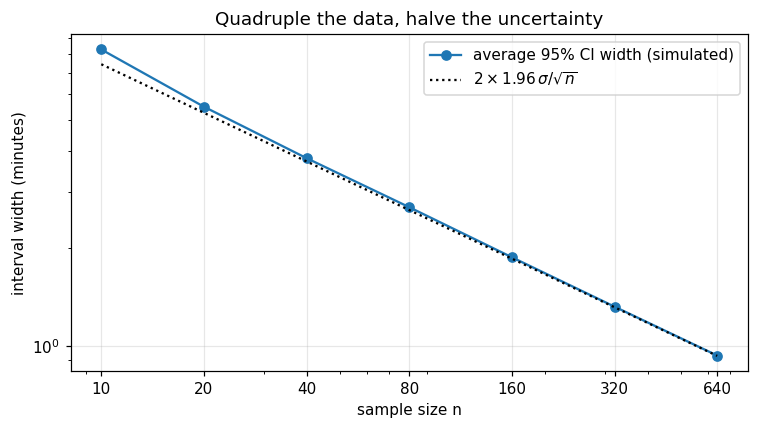

In [7]:
ns_w = np.array([10, 20, 40, 80, 160, 320, 640])
widths = []
for nn in ns_w:
    w = [np.diff(t_interval(rng.normal(TRUE_MEAN, SD, nn)))[0] for _ in range(300)]
    widths.append(np.mean(w))
fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(ns_w, widths, "o-", label="average 95% CI width (simulated)")
ax.loglog(ns_w, 2 * 1.96 * SD / np.sqrt(ns_w), "k:", label=r"$2 \times 1.96\,\sigma/\sqrt{n}$")
ax.set_xticks(ns_w, ns_w); ax.set_xlabel("sample size n"); ax.set_ylabel("interval width (minutes)")
ax.set_title("Quadruple the data, halve the uncertainty"); ax.legend()
fig.tight_layout(); fig.savefig(FIG / "w4_width_vs_n.png", dpi=150); plt.show()

## 6. Gate 1, question 4 — your answer card

**Correct:** A 95% confidence interval comes from a procedure that, over many repeated samples, produces intervals containing the true parameter 95% of the time. Any single interval either contains it or it doesn't.

**Common wrong one:** "There is a 95% probability that the true value lies inside this particular interval."

**What this notebook proved:** out of 1,000 simulated experiments, about 950 intervals contained the truth — the 95% lives in the *long run of the method*. And when the assumptions break (small, skewed samples), the real coverage drops below the promised 95%.

## 7. Your turn

1. Change the confidence level to 80% (`t_interval(x, confidence=0.80)`). Predict how many of 1,000 intervals will contain the truth, then run it.
2. Build a **99%** interval. It's wider — why is that the price of more confidence?
3. Repeat section 1 with data drawn from an Exponential distribution and $n = 10$. What coverage do you get?
4. **Explain out loud (Gate 1 Q4):** the correct meaning and the common wrong one — under 45 seconds.